In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('utils')

from utils.data_loader import DataLoader
from utils.behavioral_features import BehavioralFeatureExtractor
from utils.behavioral_visualization import BehavioralPlotter

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ All imports successful!")


✅ All imports successful!


In [2]:
# Define H5 file path
# Note: Update this path to match your actual H5 file
H5_FILE_PATH = r"D:\Data\ScienceCorp\trials_aligned.h5"  # Update this path


In [3]:
# Load H5 file and explore structure
print("📊 Loading H5 file and exploring structure...")

from utils.h5_data_loader import H5DataLoader

# Check if H5 file exists
if not Path(H5_FILE_PATH).exists():
    print(f"❌ H5 file not found: {H5_FILE_PATH}")
    print("Please update H5_FILE_PATH to point to your integrated H5 file")
else:
    # Create H5 data loader
    h5_loader = H5DataLoader(H5_FILE_PATH)
    
    # Load file metadata
    print("🔍 Loading file metadata...")
    metadata = h5_loader.load_file_metadata()
    
    print(f"\n✅ H5 file loaded successfully!")
    print(f"📁 File: {H5_FILE_PATH}")
    print(f"📊 File size: {metadata.get('file_size_mb', 0):.1f} MB")
    
    # Show global metadata
    print(f"\n🏷️ Global Metadata:")
    for key, value in metadata.items():
        if key not in ['available_trials']:
            print(f"  - {key}: {value}")
    
    # Show trial information
    print(f"\n🎯 Trial Information:")
    print(f"  - Total trials: {metadata.get('total_trials', 0)}")
    print(f"  - Available trials: {len(metadata.get('available_trials', []))}")
    print(f"  - Trial range: {min(metadata.get('available_trials', [0]))} to {max(metadata.get('available_trials', [0]))}")
    
    # Get detailed trial info
    print("\n🔍 Getting detailed trial information...")
    trial_info_df = h5_loader.get_trial_info()
    
    if len(trial_info_df) > 0:
        print(f"✅ Trial info loaded for {len(trial_info_df)} trials")
        
        # Show trial outcomes
        if 'outcome' in trial_info_df.columns:
            outcomes = trial_info_df['outcome'].value_counts()
            print(f"  - Trial outcomes: {dict(outcomes)}")
        
        # Show targets used
        if 'target_index' in trial_info_df.columns:
            targets = sorted(trial_info_df['target_index'].unique())
            print(f"  - Targets used: {targets}")
        
        # Show sample trial info
        print(f"\n📋 Sample Trial Info:")
        print(trial_info_df.head(3))
    
    print(f"\n✅ H5 file structure analysis complete!")


📊 Loading H5 file and exploring structure...
🔍 Loading file metadata...

✅ H5 file loaded successfully!
📁 File: D:\Data\ScienceCorp\trials_aligned.h5
📊 File size: 0.0 MB

🏷️ Global Metadata:
  - behavioral_file: D:\Data\ScienceCorp\actions.csv
  - creation_date: 2025-07-09T01:57:40.026325
  - final_sampling_rate: 30000
  - neural_file: D:\Data\ScienceCorp\neural.ns6
  - ns6_time_origin: 2025-03-25T21:22:53.360000+00:00
  - original_sampling_rate: 30000
  - total_trials: 140

🎯 Trial Information:
  - Total trials: 140
  - Available trials: 140
  - Trial range: 1 to 140

🔍 Getting detailed trial information...
✅ Trial info loaded for 140 trials
  - Trial outcomes: {'win': 127, 'lose': 13}
  - Targets used: [0, 1, 2, 3, 4, 5, 6, 7]

📋 Sample Trial Info:
   trial_number   duration  end_seconds                             end_time  \
0             1  36.165474    10.977080  2025-03-25T21:23:04.337080002+00:00   
1             2   2.705604    15.074401  2025-03-25T21:23:08.434401035+00:00   

In [4]:
# Initialize behavioral feature extractor for H5 data
print("🔧 Initializing behavioral feature extractor for H5 data...")

# Initialize without behavioral data (will load from H5)
feature_extractor = BehavioralFeatureExtractor()

# Load behavioral data from H5 file
if Path(H5_FILE_PATH).exists():
    print("📊 Loading behavioral data from H5 file...")
    behavioral_data = feature_extractor.load_from_h5(H5_FILE_PATH)
    
    print(f"✅ Feature extractor initialized with H5 data!")
    print(f"   - Target positions generated: {len(feature_extractor.target_positions)}")
    print(f"   - Available trials: {len(behavioral_data['trial'].unique())}")
    print(f"   - Behavioral data shape: {behavioral_data.shape}")
    
    # Show target layout
    print("\n🎯 Target Layout:")
    for target_idx, target_info in feature_extractor.target_positions.items():
        print(f"  Target {target_idx}: ({target_info['x']:.2f}, {target_info['y']:.2f}) - {target_info['direction']}")
    
    # Show sample of loaded behavioral data
    print("\n📋 Behavioral Data Sample:")
    print(behavioral_data.head())
    
else:
    print("❌ H5 file not found. Please update H5_FILE_PATH.")


🔧 Initializing behavioral feature extractor for H5 data...
📊 Loading behavioral data from H5 file...
✅ Loaded behavioral data from 140 trials
   - Total samples: 45138
   - Time span: 0 days 00:24:44.001184941
   - Trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140]
   - Trial outcomes: {'win': 127, 'lose': 13}
✅ Loaded behavioral data from H5 file: D:\Data\ScienceCorp\trials_aligned.h5
✅ Feature extractor initialized with H5 data!
   - Target pos

In [5]:
# Extract features for all trials
print("🚀 Extracting features for all trials...")
print("This may take a moment...")

# Option 1: Extract from already loaded behavioral data (faster, uses more memory)
if 'behavioral_data' in locals() and behavioral_data is not None:
    trial_numbers = sorted(behavioral_data['trial'].unique())
    print(f"Using loaded behavioral data for {len(trial_numbers)} trials...")
    
    # For initial testing, you can limit to first 50 trials
    # trial_numbers = trial_numbers[:50]
    
    all_trial_features = feature_extractor.extract_all_trials_features(trial_numbers)

# Option 2: Extract directly from H5 file (memory efficient, slightly slower)
else:
    print("Using direct H5 extraction (memory efficient)...")
    # Get available trials from H5 file
    trial_numbers = metadata.get('available_trials', [])
    
    # For initial testing, you can limit to first 50 trials
    # trial_numbers = trial_numbers[:50]
    
    print(f"Processing {len(trial_numbers)} trials...")
    all_trial_features = feature_extractor.extract_all_trials_features_from_h5(H5_FILE_PATH, trial_numbers)

print(f"\n✅ Feature extraction complete!")
print(f"   - Successfully processed: {len(all_trial_features)} trials")
print(f"   - Failed trials: {len(trial_numbers) - len(all_trial_features)}")

# Show sample features
if all_trial_features:
    sample_trial = next(iter(all_trial_features.keys()))
    sample_features = all_trial_features[sample_trial]
    
    print(f"\n📋 Sample Features (Trial {sample_trial}):")
    print(f"  - Trial outcome: {sample_features['trial_outcome']}")
    print(f"  - Target index: {sample_features['target_index']}")
    print(f"  - Reaction time: {sample_features['reaction_time']:.4f}s" if sample_features['reaction_time'] else "  - Reaction time: None")
    print(f"  - Movement time: {sample_features['movement_time']:.4f}s" if sample_features['movement_time'] else "  - Movement time: None")
    print(f"  - Endpoint error: {sample_features['endpoint_error']:.4f}" if sample_features['endpoint_error'] else "  - Endpoint error: None")
    print(f"  - Trial duration: {sample_features['trial_duration']:.4f}s")
    
    if 'path_metrics' in sample_features:
        path_metrics = sample_features['path_metrics']
        print(f"  - Path length: {path_metrics['path_length']:.4f}")
        print(f"  - Path efficiency: {path_metrics['path_efficiency']:.4f}")
    
    if 'speed_profile' in sample_features:
        speed_profile = sample_features['speed_profile']
        print(f"  - Max speed: {speed_profile['max_speed']:.4f}")
        print(f"  - Mean speed: {speed_profile['mean_speed']:.4f}")


🚀 Extracting features for all trials...
This may take a moment...
Using loaded behavioral data for 140 trials...

✅ Feature extraction complete!
   - Successfully processed: 140 trials
   - Failed trials: 0

📋 Sample Features (Trial 1):
  - Trial outcome: lose
  - Target index: 4
  - Reaction time: 32.1515s
  - Movement time: 4.0139s
  - Endpoint error: 0.5941
  - Trial duration: 36.1655s
  - Path length: 1.6897
  - Path efficiency: 0.5918
  - Max speed: 1.1909
  - Mean speed: 0.0466


In [6]:
# Compute summary statistics
print("📊 Computing summary statistics...")

summary_stats = feature_extractor.compute_summary_statistics(all_trial_features)

print(f"\n✅ Summary statistics computed!")
print(f"\n📈 Overall Performance:")
print(f"  - Total trials analyzed: {summary_stats['n_trials']}")
print(f"  - Success rate: {summary_stats['success_rate']:.2%}")
print(f"  - Successful trials: {len(summary_stats['successful_trials'])}")
print(f"  - Failed trials: {len(summary_stats['failed_trials'])}")

# Timing statistics
print(f"\n⏱️ Timing Statistics:")
if summary_stats['reaction_time']['mean'] is not None:
    print(f"  - Reaction time: {summary_stats['reaction_time']['mean']:.3f} ± {summary_stats['reaction_time']['std']:.3f}s")
    print(f"  - Reaction time median: {summary_stats['reaction_time']['median']:.3f}s")

if summary_stats['movement_time']['mean'] is not None:
    print(f"  - Movement time: {summary_stats['movement_time']['mean']:.3f} ± {summary_stats['movement_time']['std']:.3f}s")
    print(f"  - Movement time median: {summary_stats['movement_time']['median']:.3f}s")

# Accuracy statistics
print(f"\n🎯 Accuracy Statistics:")
if summary_stats['endpoint_error']['mean'] is not None:
    print(f"  - Endpoint error: {summary_stats['endpoint_error']['mean']:.3f} ± {summary_stats['endpoint_error']['std']:.3f}")
    print(f"  - Endpoint error median: {summary_stats['endpoint_error']['median']:.3f}")

# Movement statistics
print(f"\n🏃 Movement Statistics:")
if summary_stats['max_speed']['mean'] is not None:
    print(f"  - Max speed: {summary_stats['max_speed']['mean']:.3f} ± {summary_stats['max_speed']['std']:.3f}")
    print(f"  - Max speed median: {summary_stats['max_speed']['median']:.3f}")

if summary_stats['path_efficiency']['mean'] is not None:
    print(f"  - Path efficiency: {summary_stats['path_efficiency']['mean']:.3f} ± {summary_stats['path_efficiency']['std']:.3f}")
    print(f"  - Path efficiency median: {summary_stats['path_efficiency']['median']:.3f}")

# Show additional H5-specific information
if 'metadata' in locals():
    print(f"\n🔬 H5 File Information:")
    print(f"  - Source neural file: {metadata.get('neural_file', 'Unknown')}")
    print(f"  - Source behavioral file: {metadata.get('behavioral_file', 'Unknown')}")
    print(f"  - Creation date: {metadata.get('creation_date', 'Unknown')}")
    print(f"  - Original sampling rate: {metadata.get('original_sampling_rate', 'Unknown')} Hz")
    print(f"  - Final sampling rate: {metadata.get('final_sampling_rate', 'Unknown')} Hz")


📊 Computing summary statistics...

✅ Summary statistics computed!

📈 Overall Performance:
  - Total trials analyzed: 140
  - Success rate: 90.71%
  - Successful trials: 127
  - Failed trials: 13

⏱️ Timing Statistics:
  - Reaction time: 6.114 ± 28.753s
  - Reaction time median: 0.359s
  - Movement time: 2.203 ± 0.874s
  - Movement time median: 1.977s

🎯 Accuracy Statistics:
  - Endpoint error: 0.630 ± 0.171
  - Endpoint error median: 0.616

🏃 Movement Statistics:
  - Max speed: 0.796 ± 0.179
  - Max speed median: 0.788
  - Path efficiency: 4.371 ± 29.892
  - Path efficiency median: 1.858

🔬 H5 File Information:
  - Source neural file: D:\Data\ScienceCorp\neural.ns6
  - Source behavioral file: D:\Data\ScienceCorp\actions.csv
  - Creation date: 2025-07-09T01:57:40.026325
  - Original sampling rate: 30000 Hz
  - Final sampling rate: 30000 Hz


In [7]:
# Initialize behavioral plotter with corrected target positions
print("🎨 Initializing behavioral plotter...")

plotter = BehavioralPlotter(all_trial_features, feature_extractor.target_positions)

print(f"✅ Plotter initialized!")
print(f"   - Trials to plot: {len(all_trial_features)}")
print(f"   - Target positions: {len(plotter.target_positions)}")

# Verify target positions and plot scaling
print("\n📍 Verifying target positions:")
for target_idx in sorted(plotter.target_positions.keys()):
    pos = plotter.target_positions[target_idx]
    print(f"  Target {target_idx}: ({pos['x']:.3f}, {pos['y']:.3f}) - {pos['direction']}")

# Show plot scaling information
x_min, x_max, y_min, y_max = plotter._get_plot_limits()
target_size = plotter._get_target_circle_size()

print(f"\n📏 Automatic Plot Scaling:")
print(f"  - X range: {x_min:.3f} to {x_max:.3f}")
print(f"  - Y range: {y_min:.3f} to {y_max:.3f}")
print(f"  - Target circle size: {target_size:.3f}")
print(f"  - Plot area optimized for your target layout")

print("\n🎯 Ready to create visualizations with corrected target positions and optimal scaling!")


🎨 Initializing behavioral plotter...
✅ Plotter initialized!
   - Trials to plot: 140
   - Target positions: 8

📍 Verifying target positions:
  Target 0: (0.000, 1.000) - 90°
  Target 1: (0.707, 0.707) - 45°
  Target 2: (1.000, 0.000) - 0°
  Target 3: (0.707, -0.707) - -45°
  Target 4: (0.000, -1.000) - -90°
  Target 5: (-0.707, -0.707) - -135°
  Target 6: (-1.000, 0.000) - 180°
  Target 7: (-0.707, 0.707) - 135°

📏 Automatic Plot Scaling:
  - X range: -1.600 to 1.600
  - Y range: -1.600 to 1.600
  - Target circle size: 0.080
  - Plot area optimized for your target layout

🎯 Ready to create visualizations with corrected target positions and optimal scaling!


📍 Creating target position correction diagnostic...


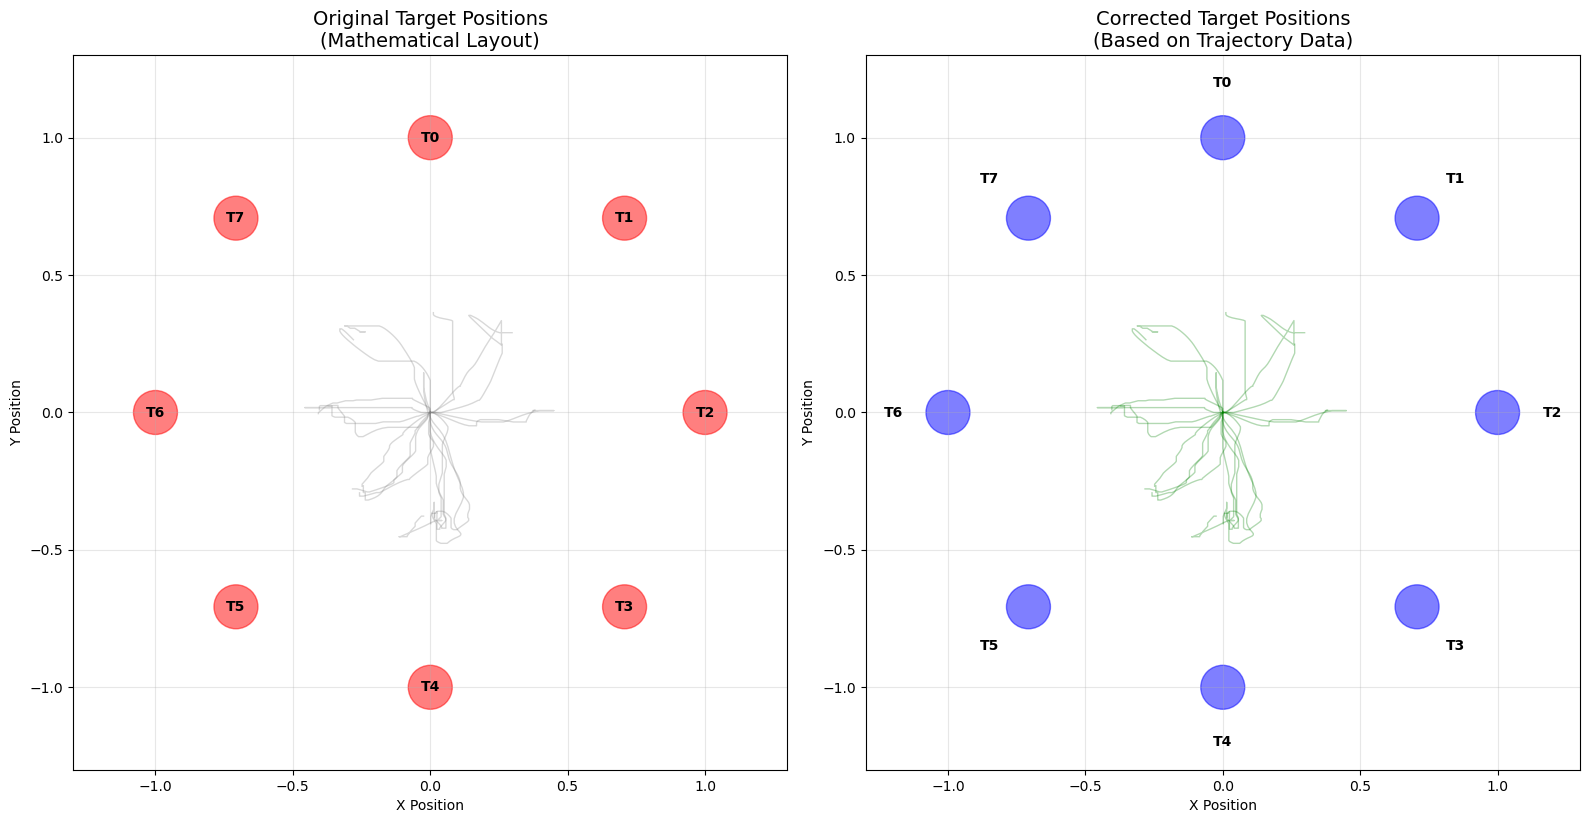

✅ Target position correction diagnostic complete!
📍 The right plot shows trajectories should now align with target circles in subsequent plots.


In [8]:
# Diagnostic: Show target position correction
print("📍 Creating target position correction diagnostic...")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Original (mathematical) positions
ax1.set_title("Original Target Positions\n(Mathematical Layout)", fontsize=14)
original_positions = BehavioralFeatureExtractor()._generate_target_positions()

# Plot trajectories to original positions
successful_trials = [trial_num for trial_num, features in all_trial_features.items() 
                   if features['trial_outcome'] == 'win'][:20]  # First 20 successful trials

for trial_num in successful_trials:
    features = all_trial_features[trial_num]
    trajectory = features.get('trajectory_data')
    if trajectory is not None and len(trajectory) > 0:
        ax1.plot(trajectory['cursor_x'], trajectory['cursor_y'], 'gray', alpha=0.3, linewidth=1)

# Plot original target circles
for target_idx, pos in original_positions.items():
    circle = plt.Circle((pos['x'], pos['y']), 0.08, color='red', alpha=0.5)
    ax1.add_patch(circle)
    ax1.text(pos['x'], pos['y'], f'T{target_idx}', ha='center', va='center', fontweight='bold')

# Get dynamic plot limits for better scaling
x_coords = [pos['x'] for pos in plotter.target_positions.values()] + [0.0]
y_coords = [pos['y'] for pos in plotter.target_positions.values()] + [0.0]

# Calculate appropriate limits with padding
x_range = max(x_coords) - min(x_coords)
y_range = max(y_coords) - min(y_coords)
padding = max(x_range, y_range) * 0.3

x_center = (max(x_coords) + min(x_coords)) / 2
y_center = (max(y_coords) + min(y_coords)) / 2

# Ensure minimum range for visibility
plot_range = max(0.5, max(x_range, y_range) + padding)

xlim = (x_center - plot_range/2, x_center + plot_range/2)
ylim = (y_center - plot_range/2, y_center + plot_range/2)

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')

# Plot 2: Corrected positions
ax2.set_title("Corrected Target Positions\n(Based on Trajectory Data)", fontsize=14)

# Plot trajectories to corrected positions
for trial_num in successful_trials:
    features = all_trial_features[trial_num]
    trajectory = features.get('trajectory_data')
    if trajectory is not None and len(trajectory) > 0:
        ax2.plot(trajectory['cursor_x'], trajectory['cursor_y'], 'green', alpha=0.3, linewidth=1)

# Calculate appropriate circle size based on target spacing
distances = [np.sqrt(pos['x']**2 + pos['y']**2) for pos in plotter.target_positions.values()]
avg_distance = np.mean(distances) if distances else 1.0
circle_size = max(0.02, min(0.15, avg_distance * 0.08))

# Plot corrected target circles
for target_idx, pos in plotter.target_positions.items():
    circle = plt.Circle((pos['x'], pos['y']), circle_size, color='blue', alpha=0.5)
    ax2.add_patch(circle)
    
    # Scale label position based on target distance
    target_distance = np.sqrt(pos['x']**2 + pos['y']**2)
    label_scale = 1.2 if target_distance > 0.1 else 2.0
    ax2.text(pos['x'] * label_scale, pos['y'] * label_scale, f'T{target_idx}', 
             ha='center', va='center', fontweight='bold')

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')

plt.tight_layout()
plt.show()

print("✅ Target position correction diagnostic complete!")
print("📍 The right plot shows trajectories should now align with target circles in subsequent plots.")


🎯 Creating cursor trajectory plots...


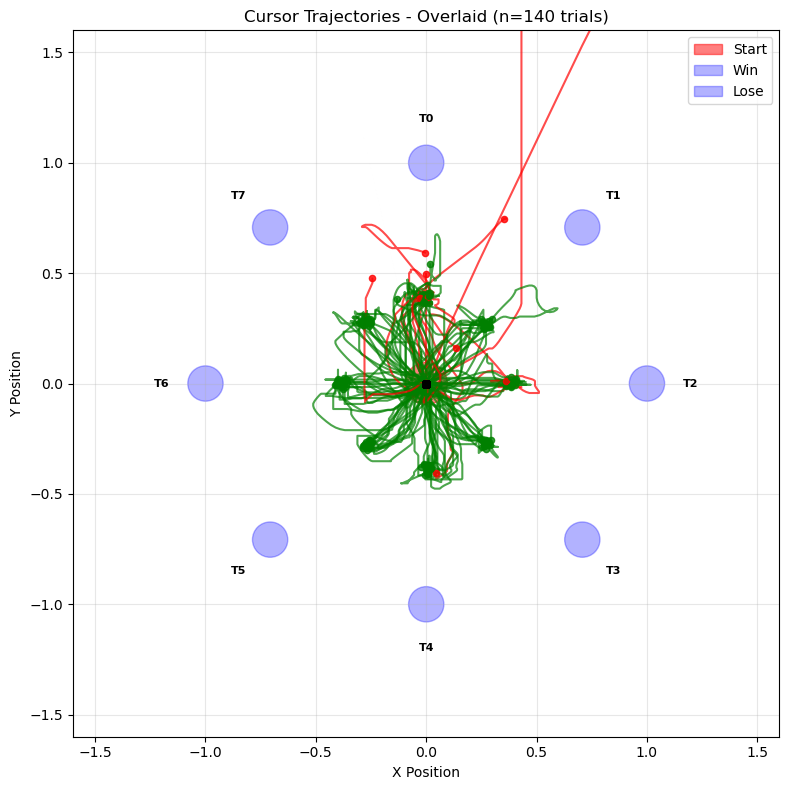

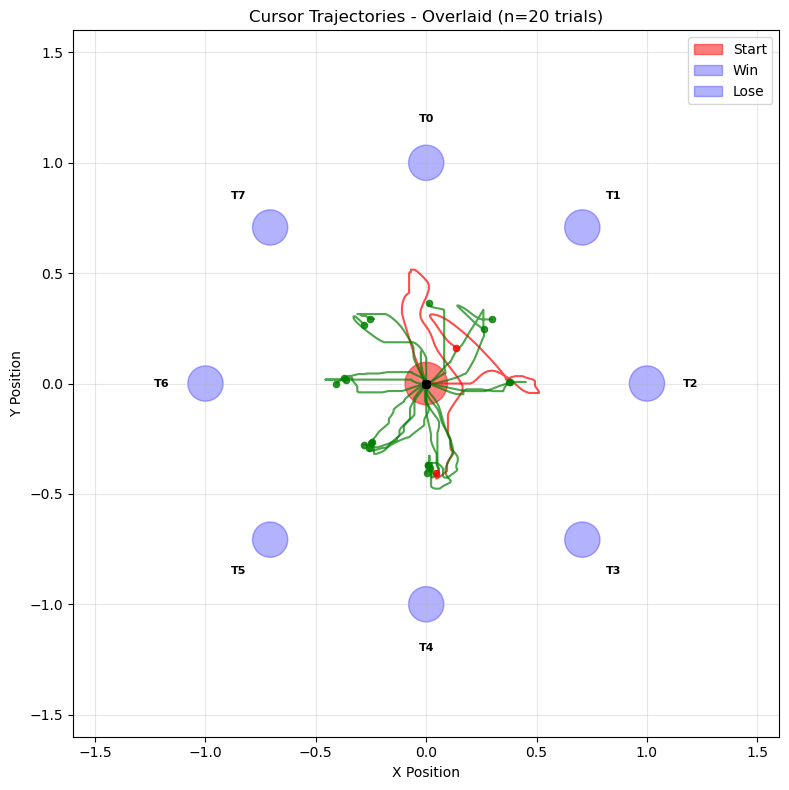

✅ Cursor trajectory plots created!


In [9]:
# Plot cursor trajectories - overlaid view
print("🎯 Creating cursor trajectory plots...")

# All trials overlaid, colored by outcome
fig1 = plotter.plot_cursor_trajectories_overlaid(color_by_outcome=True)
plt.show()

# Subset of trials for cleaner visualization
subset_trials = list(all_trial_features.keys())[:20]  # First 20 trials
fig2 = plotter.plot_cursor_trajectories_overlaid(trial_subset=subset_trials, color_by_outcome=True)
plt.show()

print("✅ Cursor trajectory plots created!")


🎯 Creating trajectories by target direction...


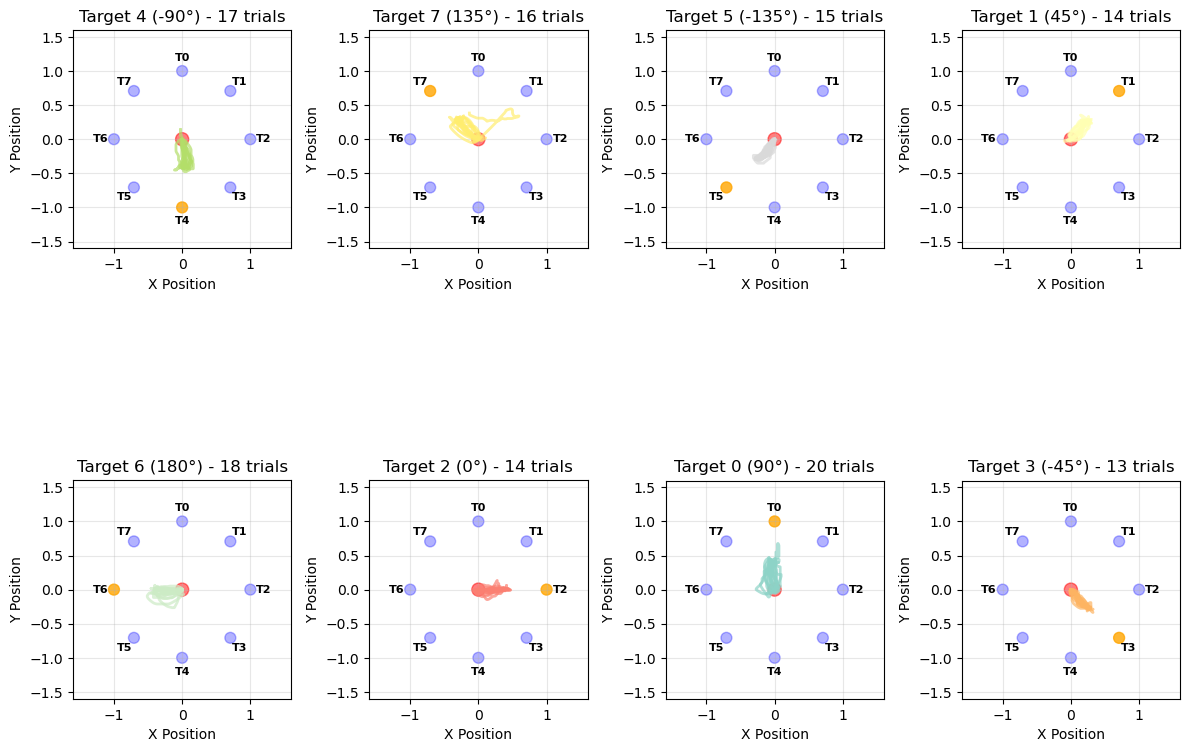

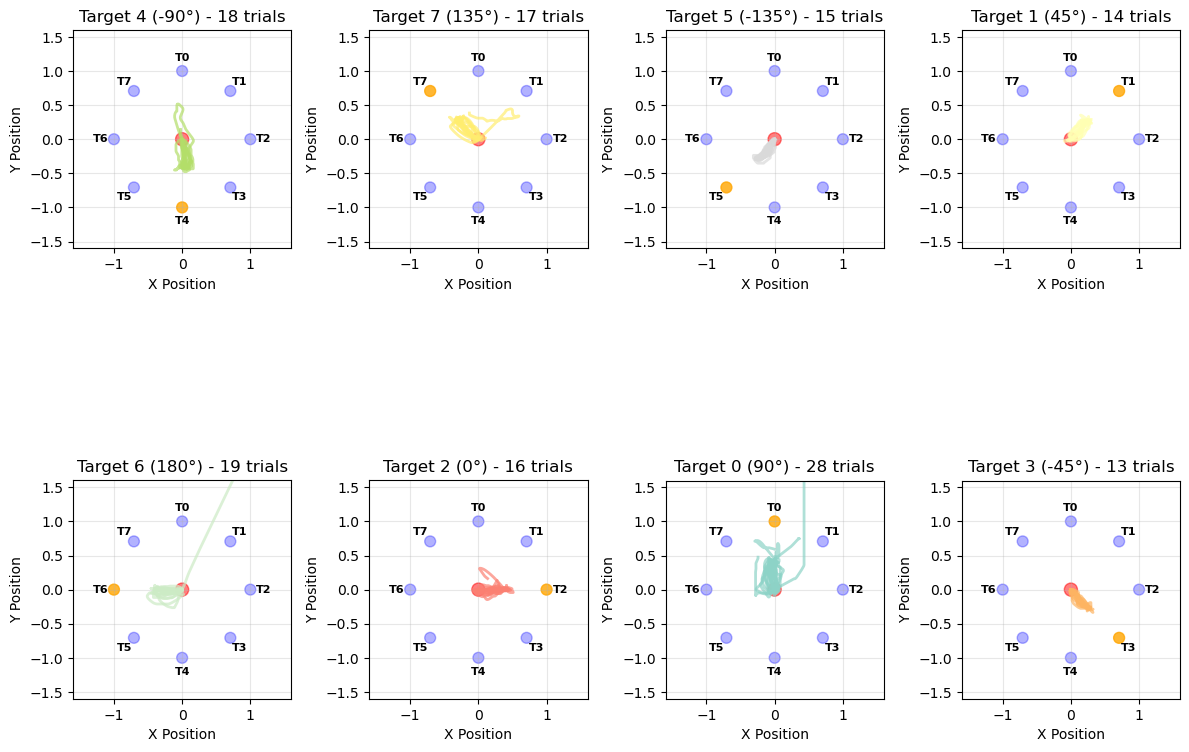

✅ Target-grouped trajectory plots created!


In [10]:
# Plot trajectories grouped by target direction
print("🎯 Creating trajectories by target direction...")

# Successful trials only, grouped by target
fig3 = plotter.plot_trajectories_by_target(successful_only=True)
plt.show()

# All trials (including failed), grouped by target
fig4 = plotter.plot_trajectories_by_target(successful_only=False)
plt.show()

print("✅ Target-grouped trajectory plots created!")


🎯 Creating correct trials overlay...


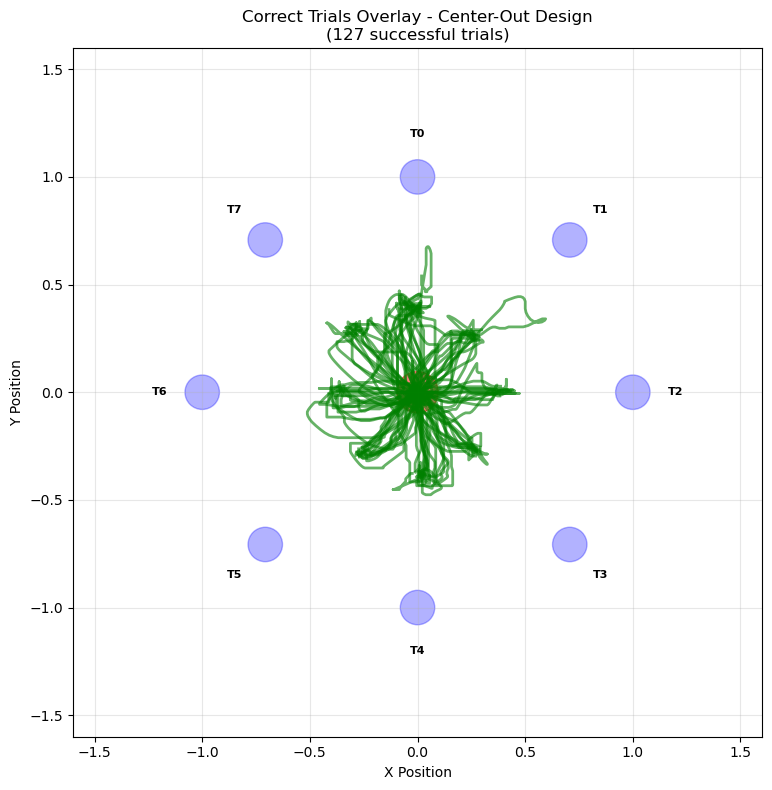

✅ Correct trials overlay created!
This visualization clearly shows the center-out design pattern.


In [11]:
# Overlay of all correct trials showing center-out design
print("🎯 Creating correct trials overlay...")

fig5 = plotter.plot_correct_trials_overlay()
plt.show()

print("✅ Correct trials overlay created!")
print("This visualization clearly shows the center-out design pattern.")


🏃 Creating speed profile plots...


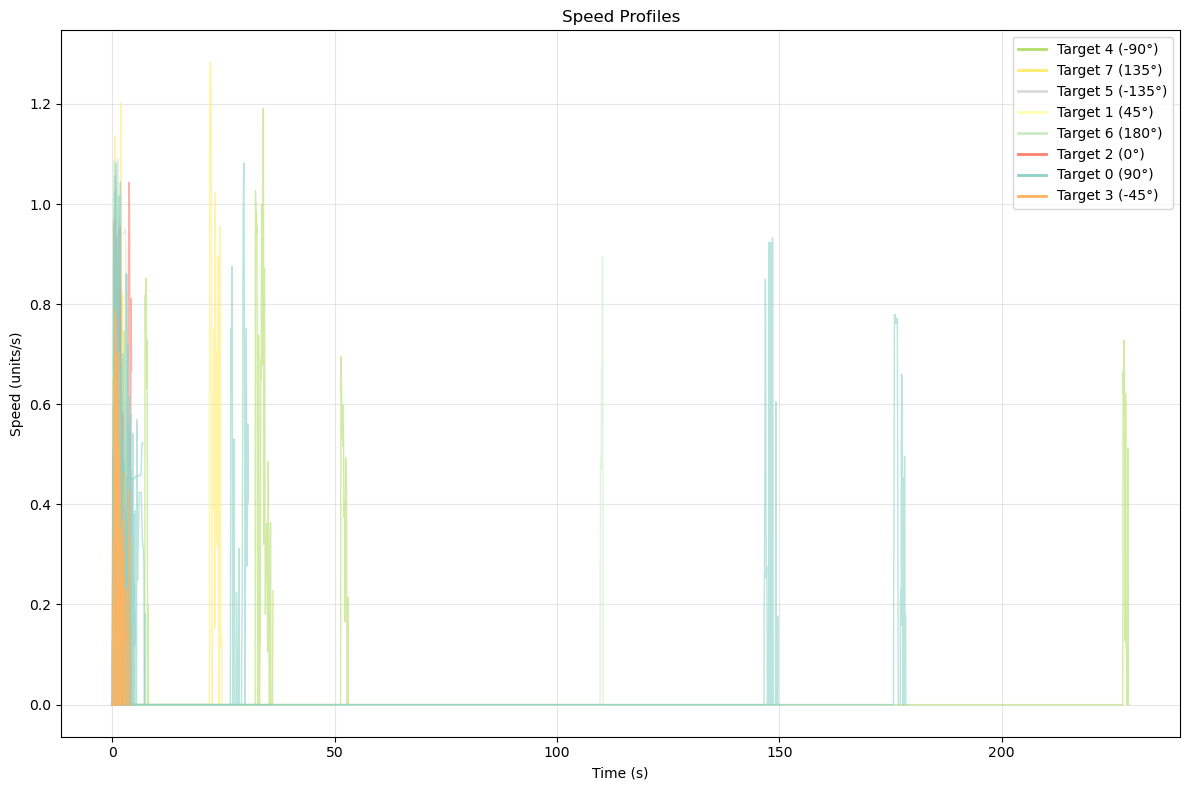

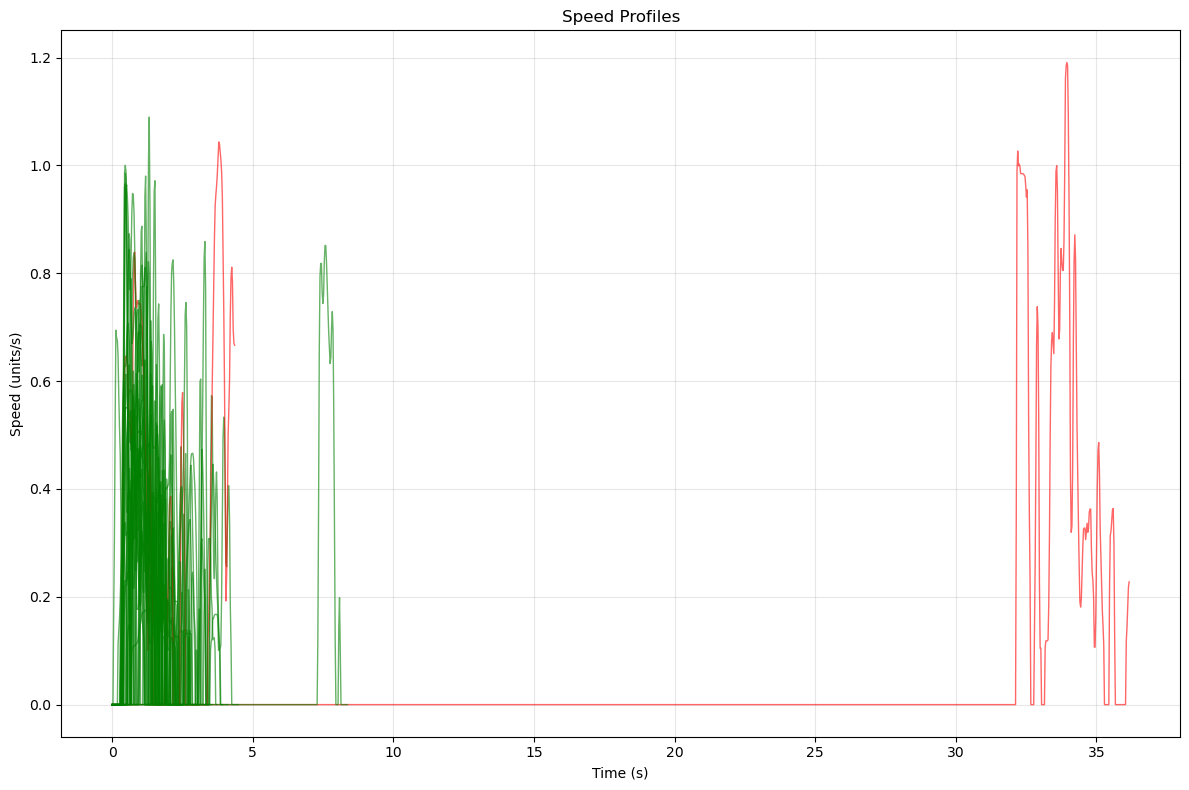

✅ Speed profile plots created!


In [12]:
# Plot speed profiles
print("🏃 Creating speed profile plots...")

# Speed profiles grouped by target direction
fig6 = plotter.plot_speed_profiles(group_by_target=True)
plt.show()

# Speed profiles for subset of trials (colored by outcome)
subset_trials = list(all_trial_features.keys())[:30]  # First 30 trials
fig7 = plotter.plot_speed_profiles(trial_subset=subset_trials, group_by_target=False)
plt.show()

print("✅ Speed profile plots created!")


⏱️ Creating timing histograms...


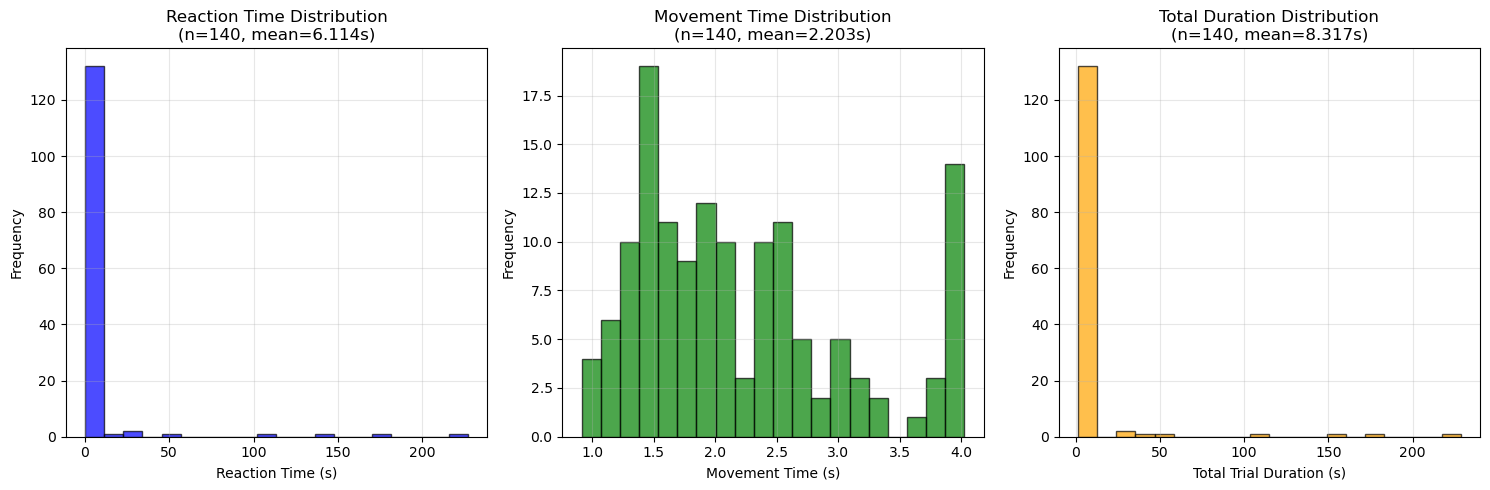

✅ Timing histograms created!


In [13]:
# Plot timing histograms
print("⏱️ Creating timing histograms...")

fig8 = plotter.plot_timing_histograms()
plt.show()

print("✅ Timing histograms created!")


⏱️ Creating timing boxplots by target...


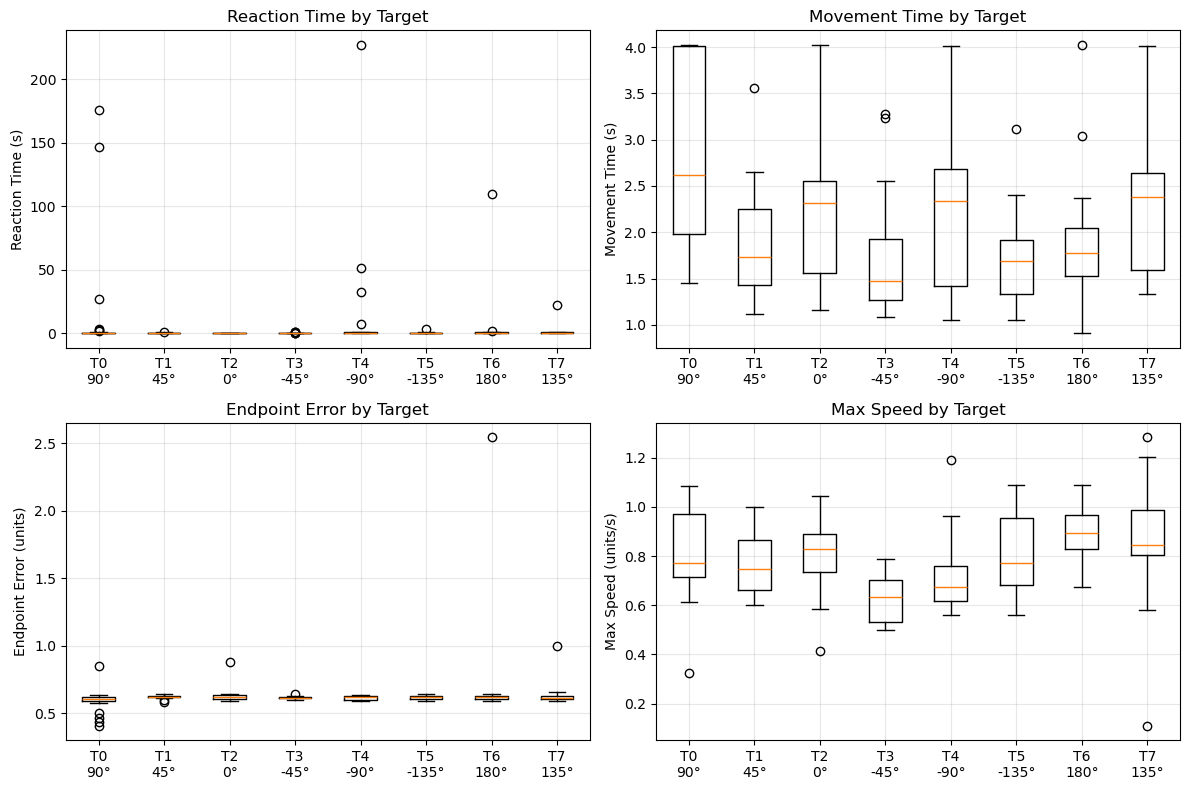

✅ Timing boxplots created!


In [14]:
# Plot timing metrics by target direction
print("⏱️ Creating timing boxplots by target...")

fig9 = plotter.plot_timing_boxplots_by_target()
plt.show()

print("✅ Timing boxplots created!")


🎯 Creating accuracy heatmaps...


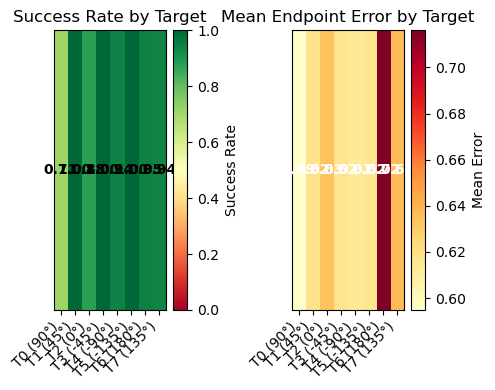

✅ Accuracy heatmaps created!


In [15]:
# Plot accuracy heatmaps
print("🎯 Creating accuracy heatmaps...")

fig10 = plotter.plot_accuracy_heatmap()
plt.show()

print("✅ Accuracy heatmaps created!")


📊 Creating success rate bar chart...


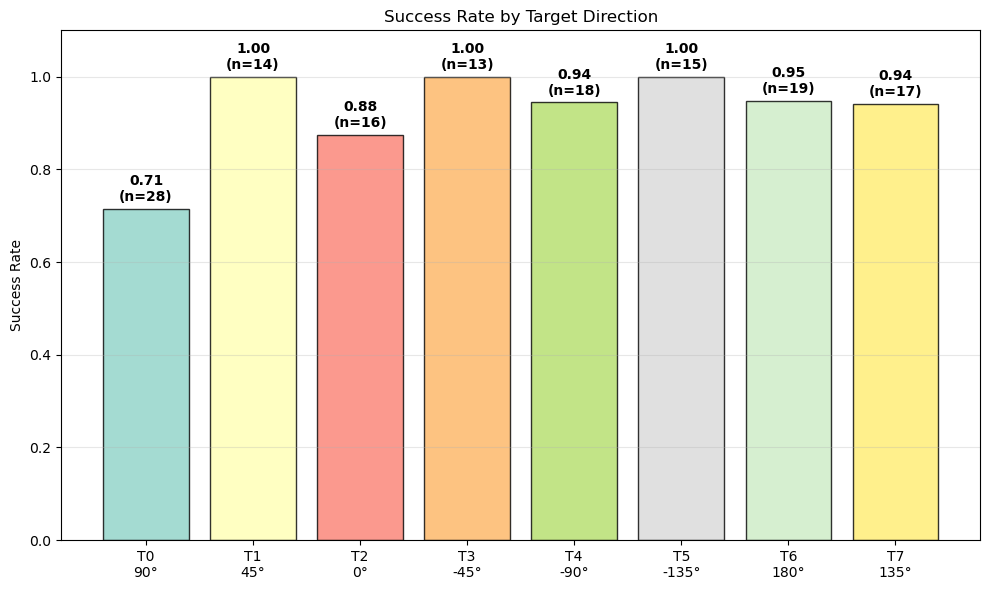

✅ Success rate bar chart created!


In [16]:
# Plot success rate by target
print("📊 Creating success rate bar chart...")

fig11 = plotter.plot_success_rate_bars()
plt.show()

print("✅ Success rate bar chart created!")


📈 Creating trial-wise trend plots...


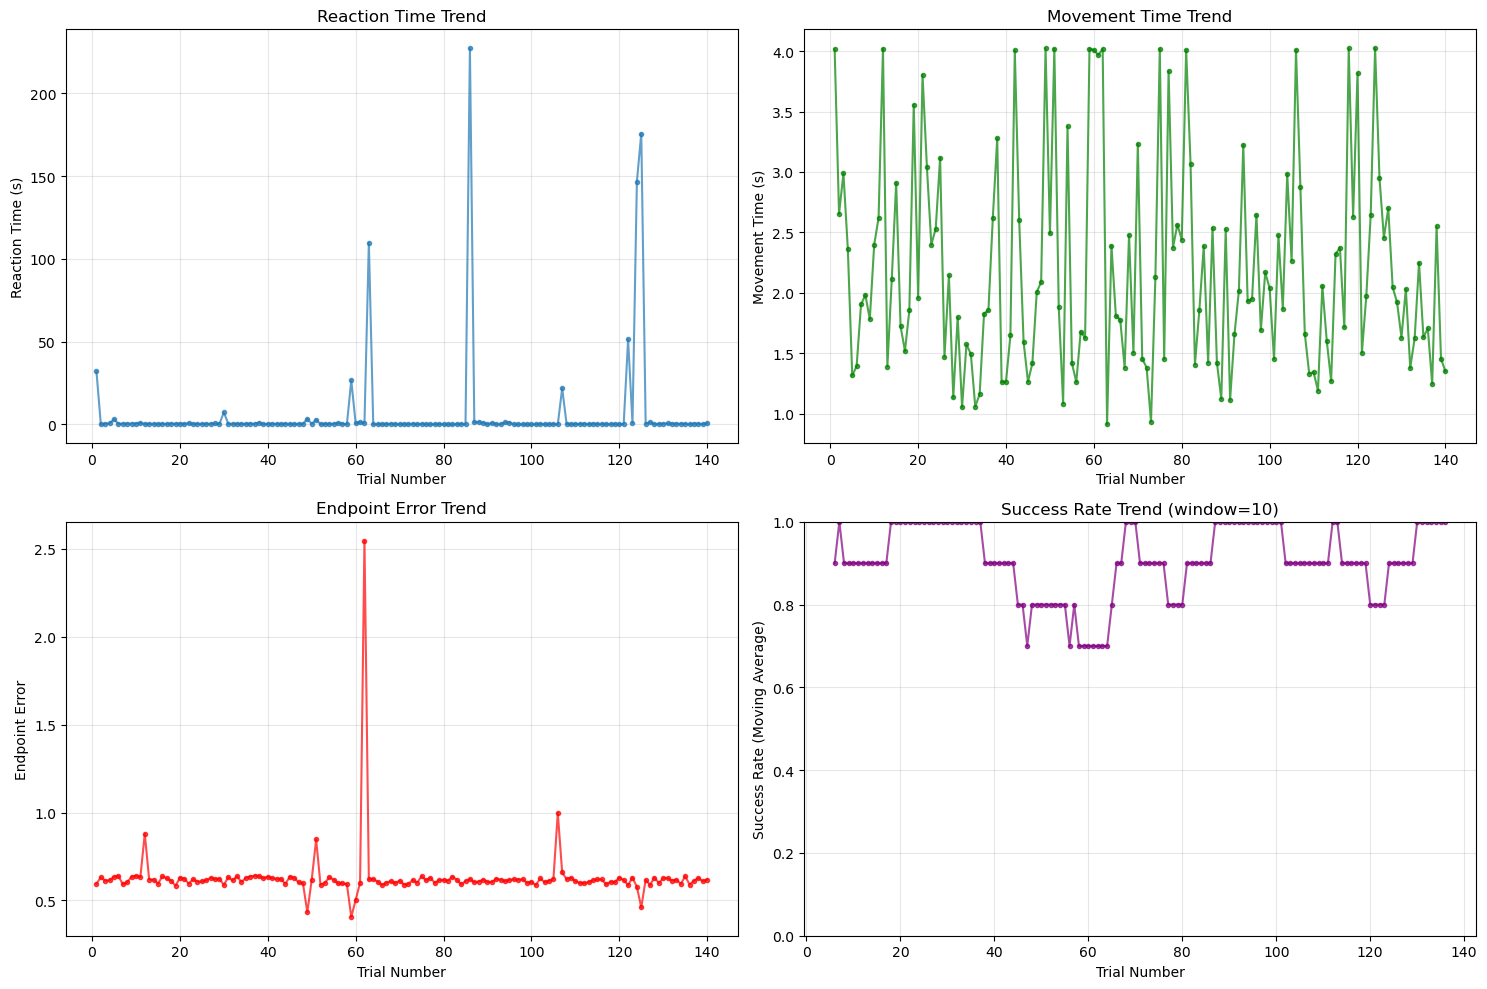

✅ Trial-wise trend plots created!
These plots show performance changes over the course of the session.


In [17]:
# Plot trial-wise trends
print("📈 Creating trial-wise trend plots...")

fig12 = plotter.plot_trial_trends()
plt.show()

print("✅ Trial-wise trend plots created!")
print("These plots show performance changes over the course of the session.")


In [18]:
# Create detailed performance summary table
print("📋 Creating detailed performance summary...")

# Collect performance metrics by target
target_performance = {}
for trial_num, features in all_trial_features.items():
    target_idx = features.get('target_index')
    if target_idx is not None:
        if target_idx not in target_performance:
            target_performance[target_idx] = {
                'trials': [],
                'successes': 0,
                'reaction_times': [],
                'movement_times': [],
                'endpoint_errors': [],
                'max_speeds': [],
                'path_efficiencies': []
            }
        
        target_performance[target_idx]['trials'].append(trial_num)
        if features['trial_outcome'] == 'win':
            target_performance[target_idx]['successes'] += 1
        
        if features['reaction_time'] is not None:
            target_performance[target_idx]['reaction_times'].append(features['reaction_time'])
        if features['movement_time'] is not None:
            target_performance[target_idx]['movement_times'].append(features['movement_time'])
        if features['endpoint_error'] is not None:
            target_performance[target_idx]['endpoint_errors'].append(features['endpoint_error'])
        if features['speed_profile'] and 'max_speed' in features['speed_profile']:
            target_performance[target_idx]['max_speeds'].append(features['speed_profile']['max_speed'])
        if features['path_metrics'] and 'path_efficiency' in features['path_metrics']:
            target_performance[target_idx]['path_efficiencies'].append(features['path_metrics']['path_efficiency'])

# Create summary table
summary_data = []
for target_idx in sorted(target_performance.keys()):
    perf = target_performance[target_idx]
    target_info = feature_extractor.target_positions.get(target_idx, {})
    
    summary_data.append({
        'Target': target_idx,
        'Direction': target_info.get('direction', ''),
        'Trials': len(perf['trials']),
        'Success Rate': perf['successes'] / len(perf['trials']) if perf['trials'] else 0,
        'Reaction Time (s)': np.mean(perf['reaction_times']) if perf['reaction_times'] else np.nan,
        'Movement Time (s)': np.mean(perf['movement_times']) if perf['movement_times'] else np.nan,
        'Endpoint Error': np.mean(perf['endpoint_errors']) if perf['endpoint_errors'] else np.nan,
        'Max Speed': np.mean(perf['max_speeds']) if perf['max_speeds'] else np.nan,
        'Path Efficiency': np.mean(perf['path_efficiencies']) if perf['path_efficiencies'] else np.nan
    })

summary_df = pd.DataFrame(summary_data)
print("\n📊 Performance Summary by Target:")
print(summary_df.round(3))

# Save summary to CSV
summary_df.to_csv('behavioral_performance_summary.csv', index=False)
print("\n💾 Summary saved to 'behavioral_performance_summary.csv'")


📋 Creating detailed performance summary...

📊 Performance Summary by Target:
   Target Direction  Trials  Success Rate  Reaction Time (s)  \
0       0       90°      28         0.714             12.897   
1       1       45°      14         1.000              0.357   
2       2        0°      16         0.875              0.284   
3       3      -45°      13         1.000              0.481   
4       4      -90°      18         0.944             18.019   
5       5     -135°      15         1.000              0.585   
6       6      180°      19         0.947              6.158   
7       7      135°      17         0.941              1.703   

   Movement Time (s)  Endpoint Error  Max Speed  Path Efficiency  
0              2.847           0.595      0.817            1.462  
1              1.910           0.618      0.770            1.991  
2              2.286           0.633      0.802            1.780  
3              1.785           0.616      0.633            2.102  
4          

In [19]:
# Optional: Manual plot scaling adjustments
print("🔧 Optional Manual Scaling Adjustments")
print("=" * 40)

print("The plots now scale automatically, but you can manually adjust if needed:")
print()
print("# Examples of manual adjustments:")
print("# plotter.set_plot_scaling(padding_factor=0.5)      # More padding around plots")
print("# plotter.set_plot_scaling(target_circle_size=0.05)  # Smaller target circles")
print("# plotter.set_plot_scaling(0.2, 0.10)              # Both padding and circle size")
print("# plotter.set_plot_scaling()                        # Reset to automatic")
print()
print("Current automatic settings are:")
x_min, x_max, y_min, y_max = plotter._get_plot_limits()
target_size = plotter._get_target_circle_size()
print(f"  - Plot range: X({x_min:.3f}, {x_max:.3f}) Y({y_min:.3f}, {y_max:.3f})")
print(f"  - Target circle size: {target_size:.3f}")
print()
print("✅ Automatic scaling should work well for most cases!")


🔧 Optional Manual Scaling Adjustments
The plots now scale automatically, but you can manually adjust if needed:

# Examples of manual adjustments:
# plotter.set_plot_scaling(padding_factor=0.5)      # More padding around plots
# plotter.set_plot_scaling(target_circle_size=0.05)  # Smaller target circles
# plotter.set_plot_scaling(0.2, 0.10)              # Both padding and circle size
# plotter.set_plot_scaling()                        # Reset to automatic

Current automatic settings are:
  - Plot range: X(-1.600, 1.600) Y(-1.600, 1.600)
  - Target circle size: 0.080

✅ Automatic scaling should work well for most cases!


In [20]:
# Troubleshooting: Additional diagnostics if needed
print("🔧 Additional Target Position Troubleshooting")
print("=" * 50)

# Check if trajectories still look misaligned
print("\n📊 Trajectory Endpoint Analysis:")

# Sample a few successful trials and show their endpoints vs target positions
sample_trials = [trial_num for trial_num, features in all_trial_features.items() 
                if features['trial_outcome'] == 'win'][:5]

print(f"{'Trial':<8} {'Target':<8} {'Endpoint':<18} {'Expected':<18} {'Error':<8}")
print("-" * 70)

for trial_num in sample_trials:
    features = all_trial_features[trial_num]
    trajectory = features.get('trajectory_data')
    target_idx = features.get('target_index')
    
    if trajectory is not None and len(trajectory) > 0 and target_idx is not None:
        # Actual endpoint
        end_x = trajectory['cursor_x'].iloc[-1]
        end_y = trajectory['cursor_y'].iloc[-1]
        
        # Expected position
        expected_pos = feature_extractor.target_positions.get(target_idx, {})
        exp_x = expected_pos.get('x', 0)
        exp_y = expected_pos.get('y', 0)
        
        # Error
        error = np.sqrt((end_x - exp_x)**2 + (end_y - exp_y)**2)
        
        print(f"{trial_num:<8} {target_idx:<8} ({end_x:.3f}, {end_y:.3f})    "
              f"({exp_x:.3f}, {exp_y:.3f})    {error:.3f}")

print(f"\n🔍 Trajectory Reconstruction Check:")
print("If errors are still large, possible issues:")
print("1. Trajectory reconstruction from velocity data may have drift")
print("2. Starting position might not be (0,0)")
print("3. Coordinate system scaling might be different")
print("4. Targets might be moving/changing during experiment")

# Check trajectory reconstruction quality
print(f"\n📏 Trajectory Quality Check:")
center_returns = []
for trial_num in sample_trials:
    features = all_trial_features[trial_num]
    trajectory = features.get('trajectory_data')
    if trajectory is not None and len(trajectory) > 0:
        start_x = trajectory['cursor_x'].iloc[0]
        start_y = trajectory['cursor_y'].iloc[0]
        center_distance = np.sqrt(start_x**2 + start_y**2)
        center_returns.append(center_distance)

if center_returns:
    avg_center_distance = np.mean(center_returns)
    print(f"  - Average starting position distance from center: {avg_center_distance:.3f}")
    if avg_center_distance > 0.1:
        print("  ⚠️  Trajectories don't start near center - check trajectory reconstruction")
    else:
        print("  ✅ Trajectories appear to start near center")

print(f"\n✅ Troubleshooting complete!")
print("If you still see misalignment, please check the trajectory reconstruction parameters.")


🔧 Additional Target Position Troubleshooting

📊 Trajectory Endpoint Analysis:
Trial    Target   Endpoint           Expected           Error   
----------------------------------------------------------------------
2        4        (0.007, -0.367)    (0.000, -1.000)    0.633
3        7        (-0.256, 0.293)    (-0.707, 0.707)    0.612
4        7        (-0.280, 0.265)    (-0.707, 0.707)    0.615
5        5        (-0.248, -0.268)    (-0.707, -0.707)    0.635
6        1        (0.262, 0.248)    (0.707, 0.707)    0.639

🔍 Trajectory Reconstruction Check:
If errors are still large, possible issues:
1. Trajectory reconstruction from velocity data may have drift
2. Starting position might not be (0,0)
3. Coordinate system scaling might be different
4. Targets might be moving/changing during experiment

📏 Trajectory Quality Check:
  - Average starting position distance from center: 0.000
  ✅ Trajectories appear to start near center

✅ Troubleshooting complete!
If you still see misalignment,

In [21]:
# Export detailed trial features
print("💾 Exporting detailed results...")

# Create detailed trial summary
trial_summary_data = []
for trial_num, features in all_trial_features.items():
    trial_data = {
        'trial_number': trial_num,
        'trial_outcome': features['trial_outcome'],
        'target_index': features['target_index'],
        'reaction_time': features['reaction_time'],
        'movement_time': features['movement_time'],
        'trial_duration': features['trial_duration'],
        'endpoint_error': features['endpoint_error']
    }
    
    # Add speed profile metrics
    if features['speed_profile']:
        trial_data.update({
            'max_speed': features['speed_profile']['max_speed'],
            'mean_speed': features['speed_profile']['mean_speed'],
            'peak_speed_time': features['speed_profile']['peak_speed_time'],
            'speed_variability': features['speed_profile']['speed_variability']
        })
    
    # Add path metrics
    if features['path_metrics']:
        trial_data.update({
            'path_length': features['path_metrics']['path_length'],
            'straight_distance': features['path_metrics']['straight_distance'],
            'path_efficiency': features['path_metrics']['path_efficiency'],
            'total_curvature': features['path_metrics']['total_curvature']
        })
    
    trial_summary_data.append(trial_data)

# Create DataFrame and save
detailed_df = pd.DataFrame(trial_summary_data)
detailed_df.to_csv('detailed_trial_features.csv', index=False)

print(f"✅ Detailed trial features exported to 'detailed_trial_features.csv'")
print(f"   - {len(detailed_df)} trials exported")
print(f"   - {len(detailed_df.columns)} features per trial")

# Show sample of exported data
print("\n📋 Sample of exported data:")
print(detailed_df.head())


💾 Exporting detailed results...
✅ Detailed trial features exported to 'detailed_trial_features.csv'
   - 140 trials exported
   - 15 features per trial

📋 Sample of exported data:
   trial_number trial_outcome  target_index  reaction_time  movement_time  \
0             1          lose             4      32.151547       4.013927   
1             2           win             4       0.052080       2.653523   
2             3           win             7       0.412719       2.987431   
3             4           win             7       0.697510       2.362061   
4             5           win             5       3.166074       1.315865   

   trial_duration  endpoint_error  max_speed  mean_speed  peak_speed_time  \
0       36.165474        0.594117   1.190866    0.046642        33.950559   
1        2.705604        0.632740   0.963762    0.361797         0.513973   
2        3.400151        0.612248   0.844127    0.176660         0.592318   
3        3.059571        0.615220   0.824793    0

In [22]:
# Final analysis summary
print("📊 BEHAVIORAL FEATURE ANALYSIS SUMMARY")
print("=" * 50)

print(f"\n📈 Dataset Overview:")
print(f"  - Total trials analyzed: {len(all_trial_features)}")
print(f"  - Data source: H5 file ({H5_FILE_PATH})")
if 'behavioral_data' in locals():
    print(f"  - Data columns: {list(behavioral_data.columns)}")
    print(f"  - Time span: {behavioral_data['timestamp'].max() - behavioral_data['timestamp'].min()}")
if 'metadata' in locals():
    print(f"  - Original data files: {metadata.get('neural_file', 'Unknown')}, {metadata.get('behavioral_file', 'Unknown')}")
    print(f"  - File creation date: {metadata.get('creation_date', 'Unknown')}")
    print(f"  - Neural sampling rate: {metadata.get('final_sampling_rate', 'Unknown')} Hz")

print(f"\n🎯 Task Performance:")
print(f"  - Overall success rate: {summary_stats['success_rate']:.2%}")
print(f"  - Successful trials: {len(summary_stats['successful_trials'])}")
print(f"  - Failed trials: {len(summary_stats['failed_trials'])}")
print(f"  - Targets used: {len(set(f['target_index'] for f in all_trial_features.values() if f['target_index'] is not None))}")

print(f"\n⏱️ Timing Analysis:")
if summary_stats['reaction_time']['mean'] is not None:
    print(f"  - Mean reaction time: {summary_stats['reaction_time']['mean']:.3f}s")
    print(f"  - Reaction time range: {min(summary_stats['reaction_time']['values']):.3f} - {max(summary_stats['reaction_time']['values']):.3f}s")

if summary_stats['movement_time']['mean'] is not None:
    print(f"  - Mean movement time: {summary_stats['movement_time']['mean']:.3f}s")
    print(f"  - Movement time range: {min(summary_stats['movement_time']['values']):.3f} - {max(summary_stats['movement_time']['values']):.3f}s")

print(f"\n🎯 Accuracy Analysis:")
if summary_stats['endpoint_error']['mean'] is not None:
    print(f"  - Mean endpoint error: {summary_stats['endpoint_error']['mean']:.3f}")
    print(f"  - Error range: {min(summary_stats['endpoint_error']['values']):.3f} - {max(summary_stats['endpoint_error']['values']):.3f}")

print(f"\n📊 Movement Characteristics:")
if summary_stats['max_speed']['mean'] is not None:
    print(f"  - Mean max speed: {summary_stats['max_speed']['mean']:.3f}")
    print(f"  - Speed range: {min(summary_stats['max_speed']['values']):.3f} - {max(summary_stats['max_speed']['values']):.3f}")

if summary_stats['path_efficiency']['mean'] is not None:
    print(f"  - Mean path efficiency: {summary_stats['path_efficiency']['mean']:.3f}")
    print(f"  - Efficiency range: {min(summary_stats['path_efficiency']['values']):.3f} - {max(summary_stats['path_efficiency']['values']):.3f}")

print(f"\n📁 Files Generated:")
print(f"  - behavioral_performance_summary.csv")
print(f"  - detailed_trial_features.csv")
print(f"  - Multiple visualization plots")

print(f"\n✅ Analysis complete! All visualizations and data exports are ready.")
print(f"\nKey findings:")
print(f"  - The center-out design is clearly visible in trajectory overlays")
print(f"  - Performance varies across target directions (see heatmaps)")
print(f"  - Behavioral trends are captured in timing and accuracy metrics")
print(f"  - Speed profiles show consistent movement patterns")


📊 BEHAVIORAL FEATURE ANALYSIS SUMMARY

📈 Dataset Overview:
  - Total trials analyzed: 140
  - Data source: H5 file (D:\Data\ScienceCorp\trials_aligned.h5)
  - Data columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial', 'trial_outcome', 'target_index', 'trial_start', 'trial_win', 'trial_lose', 'trial_duration']
  - Time span: 0 days 00:24:44.001184941
  - Original data files: D:\Data\ScienceCorp\neural.ns6, D:\Data\ScienceCorp\actions.csv
  - File creation date: 2025-07-09T01:57:40.026325
  - Neural sampling rate: 30000 Hz

🎯 Task Performance:
  - Overall success rate: 90.71%
  - Successful trials: 127
  - Failed trials: 13
  - Targets used: 8

⏱️ Timing Analysis:
  - Mean reaction time: 6.114s
  - Reaction time range: 0.025 - 227.221s
  - Mean movement time: 2.203s
  - Movement time range: 0.911 - 4.024s

🎯 Accuracy Analysis:
  - Mean endpoint error: 0.630
  - Error range: 0.407 - 2.546

📊 Movement Characteristics:
  - Mean max speed: 0.796
  - Speed range: 0.110 - 1.283
  - Mean 